In [17]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from typing_extensions import Literal
from IPython.display import display, Image
from pydantic import BaseModel, Field
import random

In [18]:
class TypeState(TypedDict):
    name: str
    game: Literal["baseball", "badminton"]

In [32]:
def pick_baseball(state: TypeState):
    print("Playing baseball game:")
    return { "game": "baseball" }


def pick_badminton(state: TypeState):
    print("Playing badminton game:")
    return { "game": "badminton" }


def play_game(state: TypeState):
    print("Starting new game:")
    return { "name": state["name"] + " want to play" }


def random_choice(state: TypeState) -> Literal["baseball", "badminton"]:
    print("Choosing random game")
    random_game = random.random()
    if random_game < 0.5:
        return "baseball"
    else:
        return "badminton"

In [33]:
builder = StateGraph(TypeState)

builder.add_node('play_game', play_game)
builder.add_node('badminton', pick_badminton)
builder.add_node('baseball', pick_baseball)

builder.add_edge(START, 'play_game')
builder.add_conditional_edges('play_game', random_choice)
builder.add_edge('badminton', END)
builder.add_edge('baseball', END)

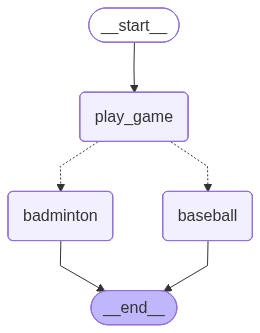

In [34]:
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
graph.invoke({ "name": "Ido" })

Starting new game:
Choosing random game
Playing badminton game:


{'name': 'Ido want to play', 'game': 'badminton'}